# S&P 500 Derin Ogrenme ile Zaman Serisi Siniflandirma

Bu notebook, S&P 500 sektor ETF'lerinin makro olaylar etrafindaki fiyat hareketlerini analiz ederek,
**T+5 gun sonra fiyatin yukselip yukselmeyecegini** tahmin eden bir **Ikili Siniflandirma (Binary Classification)** modeli kurar.

---
**Veri Seti:** `sp500_deep_learning_massive_data.csv` (~257.000 satir)
**Model:** Ileri Beslemeli Yapay Sinir Agi (Feedforward / Dense)
**Framework:** TensorFlow / Keras
**Veri Formati:** 2D — `(Orneklem Sayisi, Ozellik Sayisi)`

---
## Kutuphane Yuklemesi

In [ ]:
# ============================================================
# Temel Kutuphaneler
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Sklearn - On Isleme
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TensorFlow / Keras - Derin Ogrenme
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau


# Tekrarlanabilirlik icin rastgelelik tohumunu sabitle
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Surumu: {tf.__version__}")
print(f"NumPy Surumu: {np.__version__}")
print(f"Pandas Surumu: {pd.__version__}")
print("\nTum kutuphaneler basariyla yuklendi\!")
print()

TensorFlow Surumu: 2.20.0
NumPy Surumu: 2.0.2
Pandas Surumu: 2.3.1

Tum kutuphaneler basariyla yuklendi\!



---
## Adim 1: Veriyi Okuma ve Hedef Degisken (Y) Olusturma

**Mantik:**
Her `[Olay_Ismi, Hisse]` grubu icinde, kapanis fiyatini 5 gun ileri kaydirarak (`shift(-5)`) T+5 gun sonraki fiyati buluyoruz.
- T+5 fiyati > Bugunku fiyat → **Hedef = 1 (Yukselis)**
- T+5 fiyati <= Bugunku fiyat → **Hedef = 0 (Dusus)**

In [13]:
# ============================================================
# 1.1 - CSV Dosyasini Oku
# ============================================================
DOSYA_YOLU = "sp500_deep_learning_massive_data.csv"

df = pd.read_csv(DOSYA_YOLU)

print(f"Veri Seti Boyutu: {df.shape[0]:,} satir x {df.shape[1]} sutun")
print(f"\nSutunlar:\n{list(df.columns)}")
df.head()

Veri Seti Boyutu: 257,603 satir x 15 sutun

Sutunlar:
['Tarih', 'Olay_Ismi', 'Hisse', 'Grup', 'T0_Goreceli_Gun', 'Duzeltilmis_Kapanis', 'Log_Getiri', 'Volatilite_10g', 'Volatilite_30g', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'BBL_20_2.0', 'BBU_20_2.0']


,Tarih,Olay_Ismi,Hisse,Grup,T0_Goreceli_Gun,Duzeltilmis_Kapanis,Log_Getiri,Volatilite_10g,Volatilite_30g,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,BBL_20_2.0,BBU_20_2.0
0,1999-12-01,2000_01_TUFE,^GSPC,Gosterge_Endeks,-30,1397.719971,0.006323,0.008144,0.010864,56.087764,19.277566,-3.850734,23.128300,1350.506616,1440.185364
1,1999-12-02,2000_01_TUFE,^GSPC,Gosterge_Endeks,-29,1409.040039,0.008066,0.008454,0.010324,59.323613,18.478100,-3.720161,22.198260,1357.120509,1438.982470
2,1999-12-03,2000_01_TUFE,^GSPC,Gosterge_Endeks,-28,1433.300049,0.017071,0.009607,0.010535,65.235955,19.576431,-2.097463,21.673894,1361.330728,1441.838254
3,1999-12-06,2000_01_TUFE,^GSPC,Gosterge_Endeks,-27,1423.329956,-0.006980,0.009879,0.010524,61.293007,19.418520,-1.804300,21.222819,1365.726292,1442.752688
4,1999-12-07,2000_01_TUFE,^GSPC,Gosterge_Endeks,-26,1409.170044,-0.009998,0.010387,0.010661,56.106301,17.943940,-2.623103,20.567044,1369.496373,1442.198609


In [14]:
# ============================================================
# 1.2 - Hedef Degisken (Y) Olusturma
# ============================================================
df = df.sort_values(by=['Olay_Ismi', 'Hisse', 'T0_Goreceli_Gun']).reset_index(drop=True)

df['Fiyat_T5'] = df.groupby(['Olay_Ismi', 'Hisse'])['Duzeltilmis_Kapanis'].shift(-5)

# Hedef degiskeni olustur: 1 = Yukselis, 0 = Dusus
df['Hedef'] = (df['Fiyat_T5'] > df['Duzeltilmis_Kapanis']).astype(int)

# T+5 hesaplanamayan (NaN) satirlari sil
satirlar_once = len(df)
df = df.dropna(subset=['Fiyat_T5']).reset_index(drop=True)
satirlar_sonra = len(df)

print(f"Silinen NaN satir sayisi: {satirlar_once - satirlar_sonra:,}")
print(f"Kalan satir sayisi: {satirlar_sonra:,}")
print(f"\nHedef Degisken Dagilimi:")
print(df['Hedef'].value_counts())
print(f"\nYukselis Orani: %{df['Hedef'].mean()*100:.1f}")

Silinen NaN satir sayisi: 21,115
Kalan satir sayisi: 236,488

Hedef Degisken Dagilimi:
Hedef
1    128485
0    108003
Name: count, dtype: int64

Yukselis Orani: %54.3


---
## Adim 2: Ozellik Secimi ve 2D Veri Hazirligi

**Yaklasim:**
Kayan pencere (sliding window) veya 3 boyutlu veri hazirligi **KULLANILMIYOR**.
Veri dogrudan `(Orneklem Sayisi, Ozellik Sayisi)` boyutunda standart 2D olarak hazirlaniyor.
Her satir bagimsiz bir orneklem olarak modele veriliyor.

In [15]:
# ============================================================
# 2.1 - Ozellik Sutunlarini Sec
# ============================================================
OZELLIK_SUTUNLARI = [
    'Log_Getiri',
    'Volatilite_10g',
    'Volatilite_30g',
    'RSI_14',
    'MACD_12_26_9',
    'MACDh_12_26_9',
    'MACDs_12_26_9',
    'BBL_20_2.0',
    'BBU_20_2.0'
]

print(f"Kullanilacak Ozellik Sayisi: {len(OZELLIK_SUTUNLARI)}")
print(f"Ozellikler: {OZELLIK_SUTUNLARI}")

# Eksik deger kontrolu
eksik = df[OZELLIK_SUTUNLARI].isnull().sum()
print(f"\nOzelliklerdeki Eksik Degerler:\n{eksik[eksik > 0]}")

# Eksik degerleri olan satirlari temizle
df = df.dropna(subset=OZELLIK_SUTUNLARI).reset_index(drop=True)
print(f"\nTemizleme sonrasi kalan satir: {len(df):,}")

Kullanilacak Ozellik Sayisi: 9
Ozellikler: ['Log_Getiri', 'Volatilite_10g', 'Volatilite_30g', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'BBL_20_2.0', 'BBU_20_2.0']

Ozelliklerdeki Eksik Degerler:
Log_Getiri          9
Volatilite_10g     43
Volatilite_30g    111
dtype: int64

Temizleme sonrasi kalan satir: 236,377


In [16]:
# ============================================================
# 2.2 - 2D Veri Hazirligi (Orneklem, Ozellik)
# ============================================================
# Kayan pencere veya 3D donusum YOK.
# Her satir dogrudan bir orneklem olarak kullaniliyor.

X = df[OZELLIK_SUTUNLARI].values
y = df['Hedef'].values

print(f"X boyutu: {X.shape}  -> (Orneklem, Ozellik)")
print(f"y boyutu: {y.shape}  -> (Orneklem,)")
print(f"\nToplam orneklem sayisi: {X.shape[0]:,}")
print(f"Ozellik sayisi: {X.shape[1]}")

X boyutu: (236377, 9)  -> (Orneklem, Ozellik)
y boyutu: (236377,)  -> (Orneklem,)

Toplam orneklem sayisi: 236,377
Ozellik sayisi: 9


---
## Adim 3: Train/Test Ayrimi ve Olceklendirme (Leakage-Safe)

**Veri Sizintisini (Data Leakage) Onleme:**
- `train_test_split` ile `shuffle=False` kullaniliyor (zaman serisi sirasi korunuyor)
- `StandardScaler` sadece egitim setine `fit` ediliyor
- Ardindan hem egitim hem test setine `transform` uygulan yor

In [17]:
# ============================================================
# 3.1 - Train / Test Bolmesi (shuffle=False) + Leakage-safe Scaling
# ============================================================
# Zaman serisi oldugu icin shuffle YAPILMIYOR\!
# Gecmis veri ile egitip, gelecek veri ile test ediyoruz.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)

print(f"Bolme oncesi X boyutu: {X.shape}")
print(f"\nEgitim Seti:  X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test Seti:    X_test={X_test.shape},  y_test={y_test.shape}")

# --- Leakage-safe olceklendirme ---
# StandardScaler SADECE egitim setine fit ediliyor
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform (sadece train)
X_test  = scaler.transform(X_test)        # sadece transform (test)

print(f"\nEgitim Setindeki Yukselis Orani: %{y_train.mean()*100:.1f}")
print(f"Test Setindeki Yukselis Orani:   %{y_test.mean()*100:.1f}")
print(f"\nScaler fit edildi (sadece train): mean={scaler.mean_.round(3)}")

Bolme oncesi X boyutu: (236377, 9)

Egitim Seti:  X_train=(189101, 9), y_train=(189101,)
Test Seti:    X_test=(47276, 9),  y_test=(47276,)

Egitim Setindeki Yukselis Orani: %54.2
Test Setindeki Yukselis Orani:   %54.7

Scaler fit edildi (sadece train): mean=[ 0.00000e+00  1.80000e-02  1.90000e-02  5.23410e+01  1.68000e-01
 -3.00000e-03  1.71000e-01  1.78391e+02  1.92266e+02]


---
## Adim 4: Feedforward (Dense) Model Mimarisi

**Mimari:**
```
Input (9,) -> Dense (64, ReLU) -> Dropout (0.5) -> Dense (32, ReLU) -> Dropout (0.5) -> Dense (1, Sigmoid)
```

- **Dense (64):** Ilk gizli katman, ReLU aktivasyonu ile dogrusal olmayan oruntuleri ogrenir
- **Dense (32):** Ikinci gizli katman, ogrenilen desenleri yogunlastirir
- **Dropout (0.5):** Her gizli katmandan sonra %50 noron kapatilarak asiri ogrenme (overfitting) engellenir
- **Sigmoid:** 0-1 arasi olasilik ciktisi verir (Ikili siniflandirma icin)

> MIT 6.S191 Ders 1'de ogretilen temel yapilar: Dense katmanlar, ReLU aktivasyonu, Dropout regularizasyonu

In [ ]:
# ============================================================
# 4.1 - Feedforward (Dense) Modelini Olustur
# ============================================================
ozellik_sayisi = X_train.shape[1]  # 9 ozellik

model = Sequential([
    # Girdi Katmani
    Input(shape=(ozellik_sayisi,)),

    Dense(128,activation='swish'),

    BatchNormalization(),
    Dropout(0.2),

    # 1. Gizli Katman: 64 noron, ReLU aktivasyonu
    Dense(64, activation='swish'),
    #
    BatchNormalization(),
    
    # Dropout: %50 oraninda rastgele noron kapatma (overfitting onlemi)
    Dropout(0.2),
    
    # 2. Gizli Katman: 32 noron, ReLU aktivasyonu
    Dense(32, activation='swish'),
    
    # Dropout: %50 oraninda rastgele noron kapatma
    Dropout(0.2),
    
    # Cikti Katmani: 1 noron, Sigmoid aktivasyonu
    # 0-1 arasi olasilik uretir (Ikili siniflandirma)
    Dense(1, activation='sigmoid')
])

# Model ozetini goster
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

---
## Adim 5: Modeli Derleme ve Egitme (Compile & Fit)

**Derleme Ayarlari:**
- `loss='binary_crossentropy'`: Ikili siniflandirma icin standart kayip fonksiyonu
- `optimizer='adam'`: Adaptif ogrenme oranli optimizasyon algoritmasi
- `metrics=['accuracy']`: Dogruluk metrigi

**Egitim Ayarlari:**
- `batch_size=64`: Mini-batch yaklasimi
- `EarlyStopping(patience=10)`: Validation loss 10 epoch boyunca iyilesmezse egitimi durdur
- `class_weight` **KULLANILMIYOR** (talimat geregi)

In [19]:
# ============================================================
# 5.1 - Modeli Derle (Compile)
# ============================================================
#ozel_optimizer=Adam(learning_rate=0.0001)
ikinci_ozel_optimizer=AdamW(learning_rate=0.0001, weight_decay=0.004)
model.compile(
    loss='binary_crossentropy',       # Ikili siniflandirma kaybi
    optimizer=ikinci_ozel_optimizer,                   # Adaptif ogrenme orani
    metrics=['accuracy']                # Dogruluk metrigi
)

print("Model derlendi.")
print(f"   Loss: binary_crossentropy")
print(f"   Optimizer: ozel_optimizer")
print(f"   Metrik: Accuracy")

Model derlendi.
   Loss: binary_crossentropy
   Optimizer: ozel_optimizer
   Metrik: Accuracy


In [20]:
# ============================================================
# 5.2 - Modeli Egit (Fit)
# ============================================================
# EarlyStopping: Validation loss 10 epoch boyunca iyilesmezse dur.
# restore_best_weights: En iyi epoch'taki agirliklara geri don.

early_stopping = EarlyStopping(
    monitor='val_loss',         # Validation kaybini izle
    patience=75,                # 10 epoch sabir
    restore_best_weights=True,  # En iyi agirliklara geri don
    verbose=1
)

print("Model egitimi basliyor...\n")

gecmis = model.fit(
    X_train, y_train,
    epochs=750,                           # Maksimum 50 epoch
    batch_size=512,                       # Mini-batch: 64 orneklem
    validation_split=0.20,               # Egitim verisinin %20'si validasyon icin
    callbacks=[early_stopping],          # Asiri ogrenme korumasi
    verbose=1
)

print(f"\nEgitim tamamlandi\! Toplam epoch: {len(gecmis.history['loss'])}")

Model egitimi basliyor...

Epoch 1/750


296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5051 - loss: 0.7088 - val_accuracy: 0.5542 - val_loss: 0.6876
Epoch 2/750
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5213 - loss: 0.6989 - val_accuracy: 0.5749 - val_loss: 0.6861
Epoch 3/750
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5272 - loss: 0.6958 - val_accuracy: 0.5747 - val_loss: 0.6858
Epoch 4/750
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5320 - loss: 0.6937 - val_accuracy: 0.5752 - val_loss: 0.6856
Epoch 5/750
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5340 - loss: 0.6930 - val_accuracy: 0.5754 - val_loss: 0.6854
Epoch 6/750
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5375 - loss: 0.6917 - val_accuracy: 0.5776 - val_loss: 0.6851
Epoch 7/750
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5381 - loss: 0.6914 - val_accuracy: 0.5783 - val_loss: 0.6849
Epoch 8/750
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5386 - loss: 0.6905 - val_accuracy: 0.5794

---
## Adim 6: Modeli Degerlendirme (Evaluation)

Bu adimda:
1. Egitim surecinin **Loss** ve **Accuracy** grafiklerini cizecegiz
2. Test seti uzerinde **Loss** ve **Accuracy** degerlerini raporlayacagiz

> Talimat geregi sadece Loss ve Accuracy metrikleri kullaniliyor.
> Confusion Matrix, Recall, Precision, F1-Score **hesaplanmiyor**.

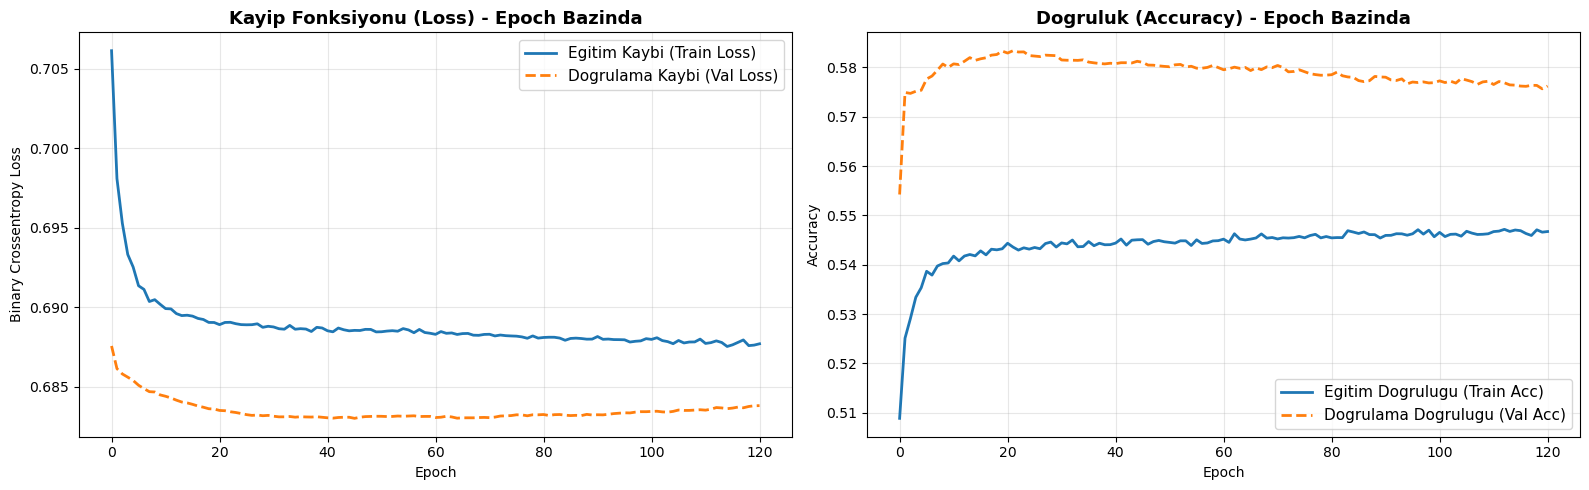


Son Epoch Istatistikleri:
   Train Loss: 0.6877
   Val Loss:   0.6838
   Fark:       0.0039
   Egitim ve dogrulama kaybi yakin -> Model dengeli ogrenmis.


In [21]:
# ============================================================
# 6.1 - Egitim Surecini Gorsellestir (Loss & Accuracy Grafikleri)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Sol Grafik: Loss (Kayip) ---
axes[0].plot(gecmis.history['loss'], label='Egitim Kaybi (Train Loss)', linewidth=2)
axes[0].plot(gecmis.history['val_loss'], label='Dogrulama Kaybi (Val Loss)', linewidth=2, linestyle='--')
axes[0].set_title('Kayip Fonksiyonu (Loss) - Epoch Bazinda', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Sag Grafik: Accuracy (Dogruluk) ---
axes[1].plot(gecmis.history['accuracy'], label='Egitim Dogrulugu (Train Acc)', linewidth=2)
axes[1].plot(gecmis.history['val_accuracy'], label='Dogrulama Dogrulugu (Val Acc)', linewidth=2, linestyle='--')
axes[1].set_title('Dogruluk (Accuracy) - Epoch Bazinda', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('egitim_grafikleri.png', dpi=150, bbox_inches='tight')
plt.show()

# Overfitting tespiti icin bilgi notu
son_train_loss = gecmis.history['loss'][-1]
son_val_loss = gecmis.history['val_loss'][-1]
fark = abs(son_train_loss - son_val_loss)
print(f"\nSon Epoch Istatistikleri:")
print(f"   Train Loss: {son_train_loss:.4f}")
print(f"   Val Loss:   {son_val_loss:.4f}")
print(f"   Fark:       {fark:.4f}")
if fark > 0.1:
    print("   Egitim ve dogrulama kaybi arasinda belirgin fark var -> Overfitting riski\!")
else:
    print("   Egitim ve dogrulama kaybi yakin -> Model dengeli ogrenmis.")

In [22]:
# ============================================================
# 6.2 - Test Seti Uzerinde Nihai Degerlendirme
# ============================================================

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("=" * 60)
print("MODEL DEGERLENDIRME OZETI")
print("=" * 60)
print(f"\n   Test Kaybi (Loss):     {test_loss:.4f}")
print(f"   Test Dogrulugu (Acc):  %{test_acc*100:.2f}")
print(f"\n   Egitim Epoch Sayisi:   {len(gecmis.history['loss'])}")
print(f"   Ozellik Sayisi:        {ozellik_sayisi}")
print(f"   Toplam Parametre:      {model.count_params():,}")
print(f"   Mimari:                Dense(64) -> Dropout(0.5) -> Dense(32) -> Dropout(0.5) -> Dense(1)")
print(f"   Aktivasyonlar:         ReLU (gizli) / Sigmoid (cikti)")
print(f"   Regularizasyon:        Dropout(0.5) + EarlyStopping(patience=10)")
print("\n" + "=" * 60)
print("Analiz tamamlandi\!")
print("=" * 60)

MODEL DEGERLENDIRME OZETI

   Test Kaybi (Loss):     0.6867
   Test Dogrulugu (Acc):  %55.77

   Egitim Epoch Sayisi:   121
   Ozellik Sayisi:        9
   Toplam Parametre:      2,753
   Mimari:                Dense(64) -> Dropout(0.5) -> Dense(32) -> Dropout(0.5) -> Dense(1)
   Aktivasyonlar:         ReLU (gizli) / Sigmoid (cikti)
   Regularizasyon:        Dropout(0.5) + EarlyStopping(patience=10)

Analiz tamamlandi\!
